In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models as sm

# Set the framework to Keras/Tensorflow
sm.set_framework('tf.keras')

# 1. Initialize U-Net with a ResNet34 backbone
# We use 'imagenet' weights so the model already understands shapes and edges
BACKBONE = 'resnet34'
model = sm.Unet(BACKBONE, encoder_weights='imagenet', classes=1, activation='sigmoid')

# 2. Load and Prepare your specific image
img_path = '/Users/rohithrk/Naruto/Projects/cnn-project/data/RawDataset/GGO/ab (8).jpg'
img = cv2.imread(img_path, cv2.IMREAD_COLOR) # Models usually expect 3 channels (RGB)
img = cv2.resize(img, (256, 256)) # U-Net typically requires powers of 2
img_input = np.expand_dims(img, axis=0) # Add batch dimension

# 3. Predict the Lung Mask
# Note: For perfect results, you would do a small 'fine-tuning' on 20-50 images
prediction = model.predict(img_input)
mask = (prediction[0, :, :, 0] > 0.5).astype(np.uint8)

# 4. Clean up the AI prediction with simple Morphological closing
kernel = np.ones((5,5), np.uint8)
final_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# 5. Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Scan (Resized)")
plt.subplot(1, 2, 2)
plt.imshow(final_mask, cmap='gray')
plt.title("AI-Generated Lung Mask")
plt.show()

AttributeError: module 'keras.utils' has no attribute 'generic_utils'

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from lungmask import mask
import SimpleITK as sitk

# 1. Load the image
img_path = '/Users/rohithrk/Naruto/Projects/cnn-project/data/RawDataset/GGO/ab (8).jpg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# 2. Convert to SimpleITK format (what the pre-trained model expects)
# We add a dummy third dimension because the model is trained on 3D volumes
sitk_img = sitk.GetImageFromArray(np.expand_dims(img, axis=0))

# 3. Run the Pre-trained U-Net Model
# model_type='unet' is the standard for 2D/3D lung segmentation
segmentation = mask.apply(sitk_img)[0] 

# 4. Process the Result
# The model returns 1 for the left lung and 2 for the right lung
lung_mask = np.where(segmentation > 0, 255, 0).astype(np.uint8)

# Fill any tiny internal holes the AI might have missed
cnts, _ = cv2.findContours(lung_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for c in cnts:
    cv2.drawContours(lung_mask, [c], -1, 255, -1)

# 5. Final Extraction
windowed = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
final_segmentation = cv2.bitwise_and(windowed, windowed, mask=lung_mask)

# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(lung_mask, cmap='gray')
plt.title("AI-Generated Stable Mask")
plt.subplot(1, 2, 2)
plt.imshow(final_segmentation, cmap='magma')
plt.title("Segmented Lung Region")
plt.show()

Downloading: "https://github.com/JoHof/lungmask/releases/download/v0.0/unet_r231-d5d2fc3d.pth" to /Users/rohithrk/.cache/torch/hub/checkpoints/unet_r231-d5d2fc3d.pth


100%|████████████████████████████████████████████████████████████████████████████████| 119M/119M [01:01<00:00, 2.02MB/s]


lungmask 2026-03-15 01:10:33 An Apple Metal device is detected and will be used. Use --cpu to disable Metal and force running on CPU.


OverflowError: Python integer 600 out of bounds for uint8

lungmask 2026-03-15 01:16:07 An Apple Metal device is detected and will be used. Use --cpu to disable Metal and force running on CPU.


1it [00:00, 32.50it/s]                                                                                                  

lungmask 2026-03-15 01:16:07 Postprocessing



100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 5423.20it/s]


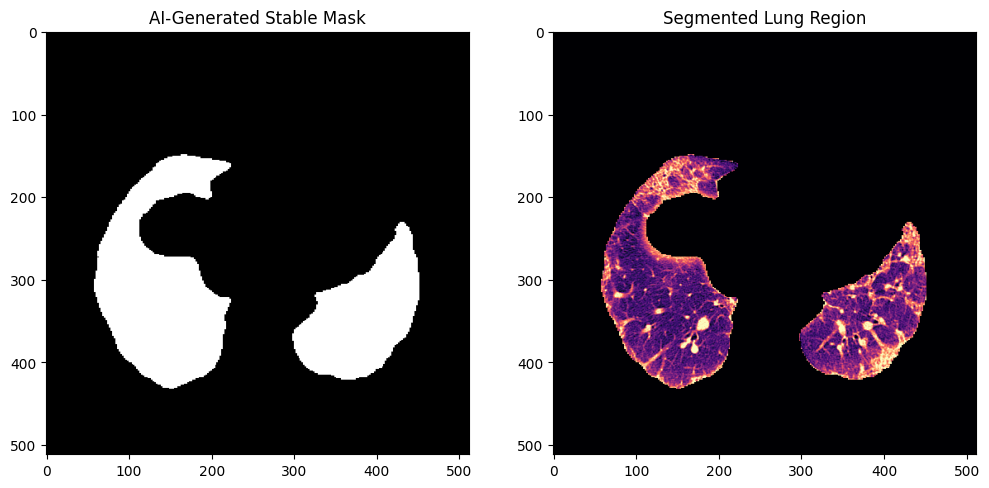

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from lungmask import mask
import SimpleITK as sitk

# 1. Load the image
# img_path = '/Users/rohithrk/Naruto/Projects/cnn-project/data/RawDataset/GGO/ab (8).jpg'
# img_path = '/Users/rohithrk/Naruto/Projects/cnn-project/data/RawDataset/GGO/g-225 (5).jpg'
img_path ='/Users/rohithrk/Naruto/Projects/cnn-project/data/RawDataset/Crazypaving/c18 (27).png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# 2. CONVERSION FIX: 
# Map your 0-255 JPG values to a typical CT range (-1024 to 0 HU)
# This prevents the OverflowError because int16 can hold '600'
img_hu = img.astype(np.int16) 
img_hu = (img_hu * 4) - 1024  # Rescale to a rough HU range

# Convert to SimpleITK format
sitk_img = sitk.GetImageFromArray(np.expand_dims(img_hu, axis=0))

# 3. Run the Pre-trained U-Net Model
# This should now run without the overflow error
segmentation = mask.apply(sitk_img)[0] 

# 4. Process the Result
# The model returns 1 for left, 2 for right lung
lung_mask = np.where(segmentation > 0, 255, 0).astype(np.uint8)

# Fill internal holes to ensure a solid lung region
cnts, _ = cv2.findContours(lung_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for c in cnts:
    cv2.drawContours(lung_mask, [c], -1, 255, -1)

# 5. Extraction for Visualization
# Use the original windowed image for the final look
windowed = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
final_segmentation = cv2.bitwise_and(windowed, windowed, mask=lung_mask)

# --- Visualization ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(lung_mask, cmap='gray')
plt.title("AI-Generated Stable Mask")
plt.subplot(1, 2, 2)
plt.imshow(final_segmentation, cmap='magma')
plt.title("Segmented Lung Region")
plt.show()
